In [2]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate
from scipy.optimize import minimize_scalar

%precision 3
%matplotlib inline
pd.set_option('display.float_format', '{:.3f}'.format)

### 연습문제1

웹사이트에서 하루동안 에러 발생 횟수를 100일간 기록한 데이터가 다음과 같다: error_counts

- 1. 위 데이터의 히스토그램
- 2. 다음 중 이 데이터에 가장 적합하다고 한단되는 확률분포는? (베르누이/이항/정규/포아송 분포 중에)
- 3. 선택한 분포의 파라미터를 데이터로부터 추정
- 4. 추정한 분포의 이론적 확률분포(확률질량함수 or 밀도함수)를 히스토그램 위에 나타낼 것

In [7]:
error_counts = np.array([
    2, 0, 1, 3, 1, 2, 0, 1, 4, 2,
    1, 0, 2, 1, 3, 2, 0, 1, 1, 2,
    3, 1, 0, 2, 1, 4, 2, 1, 0, 3,
    2, 1, 1, 0, 2, 3, 1, 2, 0, 1,
    4, 2, 1, 3, 0, 1, 2, 1, 3, 2,
    1, 0, 2, 1, 3, 1, 2, 0, 1, 4,
    2, 1, 3, 0, 1, 2, 1, 3, 2, 1,
    0, 2, 1, 3, 2, 1, 0, 1, 2, 3,
    1, 2, 0, 1, 4, 2, 1, 3, 0, 1
])

In [9]:
#2번 -> 포아송 분포 선택 : 3번 파라미터(lambda) 구하기 위해 mean 산출
lam = np.mean(error_counts)
lam

1.544

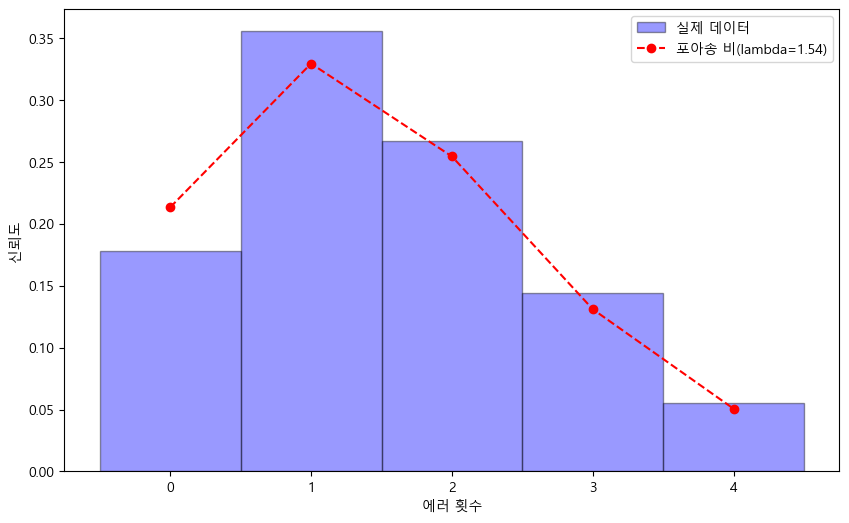

In [10]:
#1번 히스토그램
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.arange(0, error_counts.max() + 2) - 0.5
ax.hist(error_counts, bins=bins, density=True, alpha=0.4, 
        color='blue', label='실제 데이터', edgecolor='black')

#4번 이론적 확률분포
x_range = np.arange(0, error_counts.max() + 1)
# stats.poisson(mu=lam).pmf(x) 사용
pmf_values = stats.poisson(mu=lam).pmf(x_range)

ax.plot(x_range, pmf_values, 'ro--', label=f'포아송 비(lambda={lam:.2f})')
ax.set_xticks(x_range)
ax.set_xlabel('에러 횟수')
ax.set_ylabel('신뢰도')
ax.legend()
plt.show()

### 연습문제2

실험에서 관측된 연속형 데이터는 다음과 같다: data

- 1. 위 데이터의 히스토그램
- 2. 다음 중 이 데이터에 가장 적합하다고 판단되는 확률분포는? (이항/지수/정규/포아송 분포 중에)
- 3. 선택한 분포의 파라미터를 데이터로부터 추정
- 4. 추정한 분포의 이론적 확률분포(확률밀도함수)를 히스토그램 위에 나타낼 것

In [12]:
data = [
    0.2, 1.5, 0.7, 3.4, 0.1, 2.8, 0.4, 1.2, 0.6, 2.1,
    0.3, 0.9, 1.7, 0.2, 3.0, 0.5, 1.1, 0.8, 2.4, 0.1,
    0.6, 1.4, 0.3, 2.9, 0.7, 0.2, 1.0, 0.5, 3.2, 0.4,
    0.1, 1.8, 0.6, 2.6, 0.3, 0.9, 1.3, 0.2, 3.5, 0.4
]

In [14]:
#2번 -> 정규 분포 선택 : 3번 파라미터(mu, std) 구하기 위해 mean, std 산출
mu = np.mean(data)
std = np.std(data)
mu, std

(1.173, 1.033)

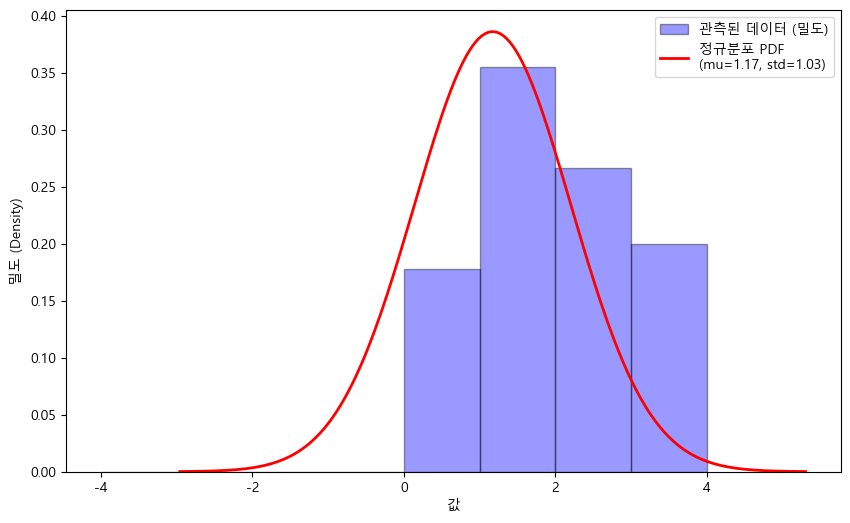

In [35]:
#1번 히스토그램
fig, ax = plt.subplots(figsize=(10, 6))
bins = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
ax.hist(error_counts, bins=bins, density=True, alpha=0.4, 
        color='blue', label='관측된 데이터 (밀도)', edgecolor='black')

#4번 이론적 확률분포
xs = np.linspace(mu - 4*std, mu + 4*std, 200)
pdf = stats.norm.pdf(xs, loc=mu, scale=std)
ax.plot(xs, pdf, 'r-', lw=2, label=f'정규분포 PDF\n(mu={mu:.2f}, std={std:.2f})')

ax.set_xlabel('값')
ax.set_ylabel('밀도 (Density)')
ax.legend()
plt.show()

### 연습문제3

다음은 어떤 확률분포에서 생성된 연속형 표본 데이터다:

- 1. 위 데이터의 히스토그램
- 2. 데이터의 표본 평균과 표준편차 계산
- 3. 데이터에 가장 적합한 연속형 확률분포 선택(정규/지수/카이제곱/t/F 분포 중에)
- 4. 추정한 분포의 이론적 확률분포(확률밀도함수)를 히스토그램 위에 나타낼 것

In [37]:
import numpy as np
np.random.seed(0)
data = np.random.normal(loc = 50, scale = 5, size = 300)
data

array([58.82 , 52.001, 54.894, 61.204, 59.338, 45.114, 54.75 , 49.243,
       49.484, 52.053, 50.72 , 57.271, 53.805, 50.608, 52.219, 51.668,
       57.47 , 48.974, 51.565, 45.73 , 37.235, 53.268, 54.322, 46.289,
       61.349, 42.728, 50.229, 49.064, 57.664, 57.347, 50.775, 51.891,
       45.561, 40.096, 48.26 , 50.782, 56.151, 56.012, 48.063, 48.488,
       44.757, 42.9  , 41.469, 59.754, 47.452, 47.81 , 43.736, 53.887,
       41.931, 48.936, 45.523, 51.935, 47.446, 44.097, 49.859, 52.142,
       50.333, 51.512, 46.828, 48.186, 46.638, 48.202, 45.934, 41.369,
       50.887, 47.991, 41.849, 52.314, 45.464, 50.26 , 53.645, 50.645,
       55.697, 43.826, 52.012, 46.576, 45.646, 47.106, 48.442, 50.281,
       44.174, 54.504, 52.328, 42.319, 57.441, 59.479, 55.894, 49.1  ,
       44.646, 55.272, 47.984, 56.112, 51.041, 54.883, 51.782, 53.533,
       50.053, 58.929, 50.635, 52.01 , 59.416, 43.261, 43.648, 54.847,
       44.134, 59.718, 47.932, 46.263, 59.615, 57.403, 59.338, 54.53 ,
      

In [ ]:
#3번 -> 정규 분포 선택(이상하면 t-분포로 갈아탈 것) : 2번 표본 평균과 표준편차 계산
mu = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)
mu, std, n

(50.138, 5.012, 300)

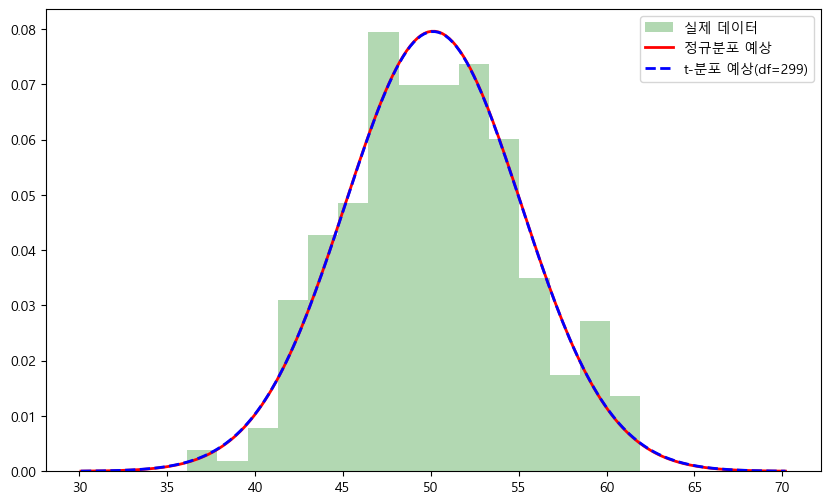

In [ ]:
#1번 히스토그램
xs = np.linspace(mu - 4*std, mu + 4*std, 200)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data, bins=15, density=True, alpha=0.3, color='green', label='실제 데이터')

# 4번 이론적 확률 분포 비교 및 선택
# 정규분포 (빨간 실선)
ax.plot(xs, stats.norm.pdf(xs, mu, std), 'r-', lw=2, label='정규분포 예상')

# t-분포 (파란 점선, 자유도 n-1)
ax.plot(xs, stats.t.pdf(xs, df=n-1, loc=mu, scale=std), 'b--', lw=2, label=f't-분포 예상(df={n-1})')

ax.legend()
plt.show()

t-분포와 정규분포의 그래프가 똑같이 그려지는 것으로 보아 정규분포를 선택하는 것이 맞다
- Gemini 왈
> 정규분포를 가장 먼저 그려보는 것이 통계 분석의 표준적인 순서입니다. 대부분의 연속형 데이터는 정규분포를 가정한 후, 거기서 얼마나 벗어나는지를 확인하며 분석을 확장하기 때문입니다.

### 연습문제4

각 시스템에서 두 서버 그룹 A와 B의 응답 시간(ms) 변동성을 비교하고자 한다. 각 그룹에서 30일간 하루에 한 번씩 측정한 응답 시간 데이터는 다음과 같다: A, B

- 1. 각 그룹 A, B의 표본분산 계산
- 2. 두 분산을 이용한 F 값
- 3. 위에서 계산한 F값이 따르는 F분포의 자유도(n1, n2) 구하기
- 4. 자유도(n1, n2)를 가지는 F분포의 확률밀도함수(pdf)

In [40]:
A = [
    210, 215, 198, 205, 220, 225, 199, 207, 212, 218,
    203, 210, 206, 214, 221, 209, 202, 208, 217, 223,
    205, 211, 204, 219, 226, 200, 206, 213, 216, 222
]
B = [
    205, 260, 190, 240, 210, 275, 185, 255, 200, 265,
    195, 250, 205, 270, 180, 260, 190, 245, 200, 280,
    185, 255, 195, 275, 180, 265, 190, 250, 200, 270
]

In [69]:
#1번
var_A = np.var(A, ddof=1)
var_B = np.var(B, ddof=1)
var_A, var_B

(63.637, 1270.259)

In [68]:
#2번
f_sample = var_B / var_A
f_sample

19.961

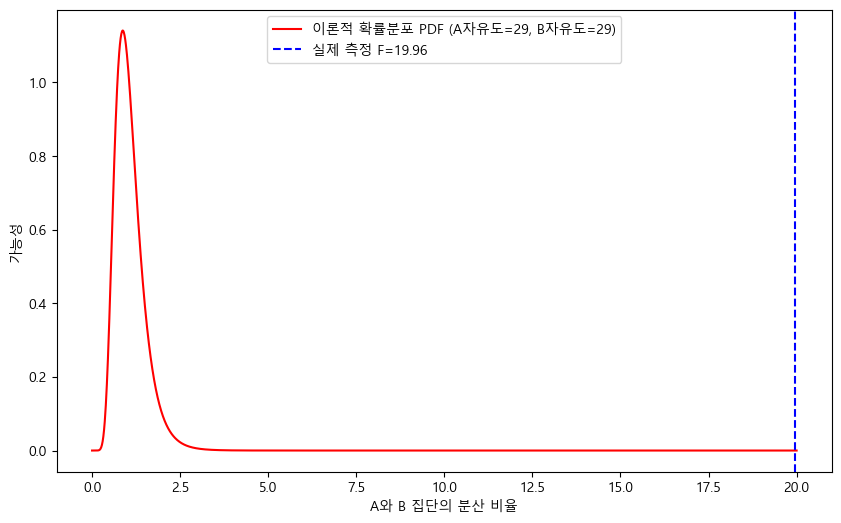

In [ ]:
#3~4번
n1 = 30 - 1
n2 = 30 - 1

rv_f = stats.f(n1, n2)
xs = np.linspace(0, 20, 2000)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xs, rv_f.pdf(xs), 'r-', label=f'이론적 확률분포 PDF (A자유도={n1}, B자유도={n2})')
ax.axvline(f_sample, color='blue', ls='--', label=f'실제 측정 F={f_sample:.2f}')

ax.set_xlabel('A와 B 집단의 분산 비율')
ax.set_ylabel('가능성')
ax.legend()
plt.show()

두 그래프가 만나는 지점이 F분포값(19.96) 자리이므로, B 집단은 A 집단과 비교했을 때 서버 응답 시간 변동성(분산)이 큰 것을 알 수 있음.
- Gemini 왈
> "이론상(빨간 곡선)으로는 1 근처 값이 나와야 하는데, 실제(파란 선)로는 너무 먼 값이 나왔으므로, 두 서버 그룹의 변동성은 우연히 같다고 볼 수 없을 만큼 확연히 차이가 난다"는 사실을 이 두 축의 관계가 증명해 주는 것입니다.